# 딥러닝 3일차

In [142]:
import keras
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [143]:
# 실행할 때마다 랜덤 값이 동일하게 나오고 싶으면. seed 지정할 것.
# keras.utils.set_random_seed(42)
# tf.random.set_seed(42)
# tf.config.experimental.enable_op_determinism()

In [144]:
# 데이터 불러오기 (학습 데이터만)
(train_input, train_target), _ = keras.datasets.fashion_mnist.load_data()
train_scale = train_input / 255.0


In [145]:
# 데이터 분할
train_scaled, val_scaled, train_target, val_target = train_test_split(train_scale, train_target, test_size=0.2)

In [146]:
train_scaled.shape, val_scaled.shape

((48000, 28, 28), (12000, 28, 28))

In [147]:
# 모델 생성 함수
def model_fn(a_layer=None):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(28,28)))  # 입력
    model.add(keras.layers.Flatten())  # 평탄화 784
    model.add(keras.layers.Dense(100, activation='relu'))  # 은닉층
    if a_layer:
        model.add(a_layer)     # 매개변수가 있는 경우에만 선택적으로 삽입하는 layer
    model.add(keras.layers.Dense(10, activation='softmax')) # 출력층
    return model

In [148]:
model = model_fn()
model.compile(loss=keras.losses.sparse_categorical_crossentropy, metrics=[keras.metrics.sparse_categorical_accuracy])
# model.compile(loss='sparse_catergorical_crosentropy', metrics=['accuracy']) # 문자열 입력
history = model.fit(train_scaled, train_target, epochs=5) # 학습 후 history 객체 반환

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.5340 - sparse_categorical_accuracy: 0.8119
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3973 - sparse_categorical_accuracy: 0.8558
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3572 - sparse_categorical_accuracy: 0.8727
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3364 - sparse_categorical_accuracy: 0.8784
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3211 - sparse_categorical_accuracy: 0.8851


In [149]:
history.history.keys()

dict_keys(['loss', 'sparse_categorical_accuracy'])

In [150]:
history.history['loss']

[0.5340126752853394,
 0.3973122537136078,
 0.35716527700424194,
 0.3363695740699768,
 0.3210618495941162]

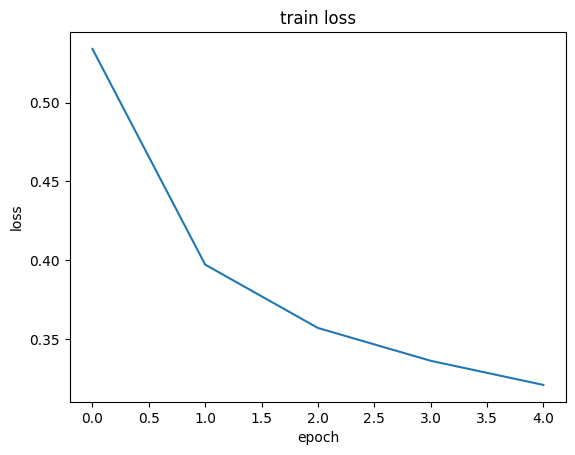

In [151]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('train loss')
plt.show()

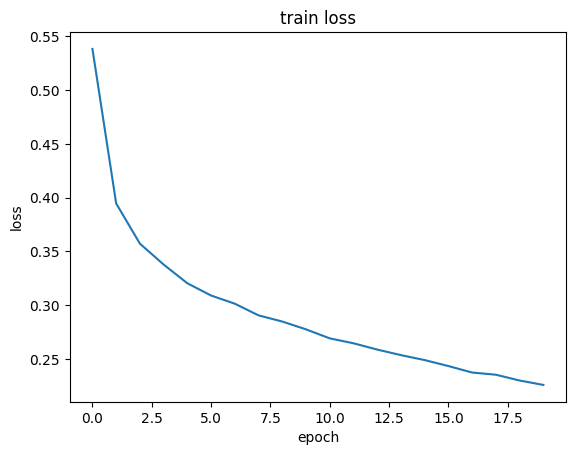

In [152]:
# 20 epoch의 손실 곡선
model = model_fn()
model.compile(loss=keras.losses.sparse_categorical_crossentropy, metrics=[keras.metrics.sparse_categorical_accuracy])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0)  # 에폭 20, 출력 없이

plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('train loss')
plt.show()

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.5366 - sparse_categorical_accuracy: 0.8099 - val_loss: 0.4186 - val_sparse_categorical_accuracy: 0.8533
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3968 - sparse_categorical_accuracy: 0.8564 - val_loss: 0.3685 - val_sparse_categorical_accuracy: 0.8681
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3586 - sparse_categorical_accuracy: 0.8706 - val_loss: 0.3647 - val_sparse_categorical_accuracy: 0.8689
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3342 - sparse_categorical_accuracy: 0.8794 - val_loss: 0.3474 - val_sparse_categorical_accuracy: 0.8791
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3211 - sparse_categorical_accuracy: 0.8842 - val_loss: 0.3824 - val_sparse_categorical_accuracy: 0.8691
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3098 - sparse_categorical_accuracy: 0.8891 - val_loss: 0.3545 - val_sparse_categorical_accuracy:

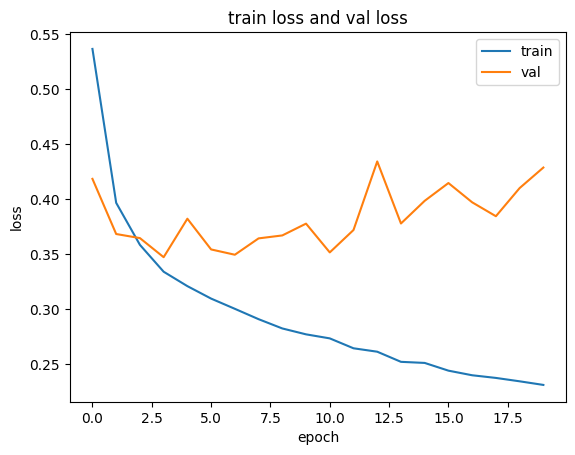

In [153]:
# validation 검증 데이터와 손실(loss) 비교
model = model_fn()
# optimizer : rmsprop
model.compile(loss=keras.losses.sparse_categorical_crossentropy, metrics=[keras.metrics.sparse_categorical_accuracy])
history = model.fit(train_scaled, train_target, epochs=20,
                    validation_data=(val_scaled, val_target))  

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('train loss and val loss')
plt.show()

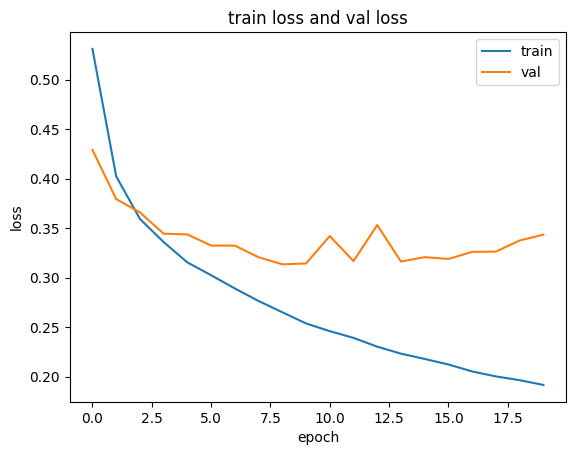

In [154]:
# validation 검증 데이터와 손실(loss) 비교
model = model_fn()
# optimizer : adam
model.compile(optimizer='adam',
            loss=keras.losses.sparse_categorical_crossentropy, 
              metrics=[keras.metrics.sparse_categorical_accuracy])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))  

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('train loss and val loss')
plt.show()

## DropOut

In [155]:
model = model_fn(a_layer=keras.layers.Dropout(0.3))  # 드롭 아웃 층을 추가
model.summary()  # 파라미터 수는 변화가 없음.
# 뉴런을 끄는 연산만 하고, 가중치는 그대로이기 때문에, 파라미터 수는 변화가 없다.

Model: "sequential_45"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_45 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_88 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

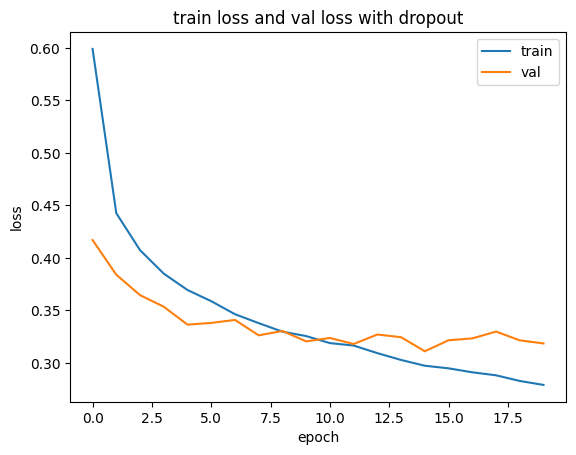

In [156]:
model.compile(optimizer='adam',
              loss=keras.losses.sparse_categorical_crossentropy, 
              metrics=[keras.metrics.sparse_categorical_accuracy])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target))  

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('train loss and val loss with dropout')
plt.show()

In [157]:
history.history['loss']

[0.5989325642585754,
 0.4424974322319031,
 0.40727946162223816,
 0.38494575023651123,
 0.3693472445011139,
 0.3587009310722351,
 0.3463101387023926,
 0.33779507875442505,
 0.3296864330768585,
 0.3254706561565399,
 0.31879764795303345,
 0.31647077202796936,
 0.309235543012619,
 0.3027212619781494,
 0.2972356677055359,
 0.2947615683078766,
 0.29098182916641235,
 0.288133829832077,
 0.2827361524105072,
 0.2789636254310608]

In [158]:
# 드롭아웃 외에도 정규화 방법들이 존재
# L2 정규화 : 수학적 해석 명확, 소규모 데이터셋에서 안정적으로 작동, 랜덤 요소 없음.
# model.add(keras.layers.Dense(100, activation='relu', kernel_regularizer='l2'))

# Dropout : 컴퓨터비전(CV)에서 표준.

## 모델 저장

In [159]:
model.save('model.keras') # 모델의 구조와 가중치를 모두 저장

In [160]:
# 가중치만 저장
model.save_weights('model.weights.h5')  # HDF5 포맷으로 저장

In [161]:
model2 = model_fn(keras.layers.Dropout(0.3))
model2.load_weights('model.weights.h5')  # 같은 구조의 모델은 가중치만 불러오기 가능

In [162]:
# compile, fit 없어도, 바로 예측 가능.
model2.predict(val_scaled)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 727us/step


array([[6.7784862e-14, 5.6525098e-18, 9.3177870e-16, ..., 9.9666363e-01,
        5.0402971e-09, 9.4776976e-07],
       [5.4270026e-07, 8.9317997e-11, 5.3195238e-02, ..., 1.9858287e-10,
        1.8872437e-07, 1.0073365e-11],
       [3.5859288e-05, 3.6643255e-10, 7.3173046e-01, ..., 7.1658205e-12,
        1.0757935e-06, 4.1529098e-12],
       ...,
       [6.6503979e-14, 2.8689598e-26, 2.9695622e-20, ..., 4.1418344e-15,
        2.5707413e-16, 1.6156316e-13],
       [1.9964553e-07, 2.1798659e-12, 1.0782850e-04, ..., 8.1726025e-15,
        5.4789790e-09, 6.8586369e-17],
       [8.3791628e-04, 5.0784984e-06, 7.0763719e-01, ..., 4.8532684e-15,
        2.7487113e-05, 2.0843931e-11]], shape=(12000, 10), dtype=float32)

In [163]:
model3 = keras.models.load_model('model.keras')
model3.evaluate(val_scaled, val_target)  # 바로 확인 가능 loss, accuracy

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 967us/step - loss: 0.3185 - sparse_categorical_accuracy: 0.8905


[0.31847745180130005, 0.890500009059906]

## CallBack
- 학습(fit) 실행 중, 특정 이벤트에 자동으로 동작하는 함수.

In [164]:
checkpoint = keras.callbacks.ModelCheckpoint('best-model.keras', 
                                save_best_only=True) # 최적의 val_loss 개선될 때만 저장

In [165]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam',
              loss=keras.losses.sparse_categorical_crossentropy, 
              metrics=[keras.metrics.sparse_categorical_accuracy])
history = model.fit(train_scaled, train_target, epochs=20, verbose=1,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint]  # 콜백 함수 추가 
                    )  


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.5993 - sparse_categorical_accuracy: 0.7890 - val_loss: 0.4381 - val_sparse_categorical_accuracy: 0.8462
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4380 - sparse_categorical_accuracy: 0.8431 - val_loss: 0.3769 - val_sparse_categorical_accuracy: 0.8673
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.4045 - sparse_categorical_accuracy: 0.8528 - val_loss: 0.3805 - val_sparse_categorical_accuracy: 0.8593
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3811 - sparse_categorical_accuracy: 0.8607 - val_loss: 0.3455 - val_sparse_categorical_accuracy: 0.8756
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3667 - sparse_categorical_accuracy: 0.8656 - val_loss: 0.3297 - val_sparse_categorical_accuracy: 0.8835
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3554 - sparse_categorical_accuracy: 0.8697 - val_loss: 0.3302 - val_sparse_categorical_accuracy:

In [166]:
# 최적의 모델 불러오기
model_best = keras.models.load_model('best-model.keras')

In [167]:
model_best.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3150 - sparse_categorical_accuracy: 0.8860  


[0.3150428533554077, 0.8859999775886536]

## 조기종료

In [168]:
early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss",    # val_loss 모니터링하다가
                              patience=2,            # 2 에폭보다 개선 없으면
                              restore_best_weights=True # 가장 좋았던때로 복원
                              )

In [169]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam',
              loss=keras.losses.sparse_categorical_crossentropy, 
              metrics=[keras.metrics.sparse_categorical_accuracy])
history = model.fit(train_scaled, train_target, epochs=20, verbose=1,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint, early_stopping]  # 콜백 함수 추가 + 조기종료
                    )  

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.5950 - sparse_categorical_accuracy: 0.7916 - val_loss: 0.4236 - val_sparse_categorical_accuracy: 0.8487
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.4401 - sparse_categorical_accuracy: 0.8414 - val_loss: 0.3974 - val_sparse_categorical_accuracy: 0.8561
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.4076 - sparse_categorical_accuracy: 0.8517 - val_loss: 0.3594 - val_sparse_categorical_accuracy: 0.8645
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3849 - sparse_categorical_accuracy: 0.8609 - val_loss: 0.3520 - val_sparse_categorical_accuracy: 0.8693
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3710 - sparse_categorical_accuracy: 0.8638 - val_loss: 0.3447 - val_sparse_categorical_accuracy: 0.8712
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3571 - sparse_categorical_accuracy: 0.8688 - val_loss: 0.3310 - val_sparse_categorical_accuracy:

In [170]:
early_stopping.stopped_epoch  # 멈춘 에폭은 12

8

In [171]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step - loss: 0.3247 - sparse_categorical_accuracy: 0.8771


[0.3247097432613373, 0.8770833611488342]